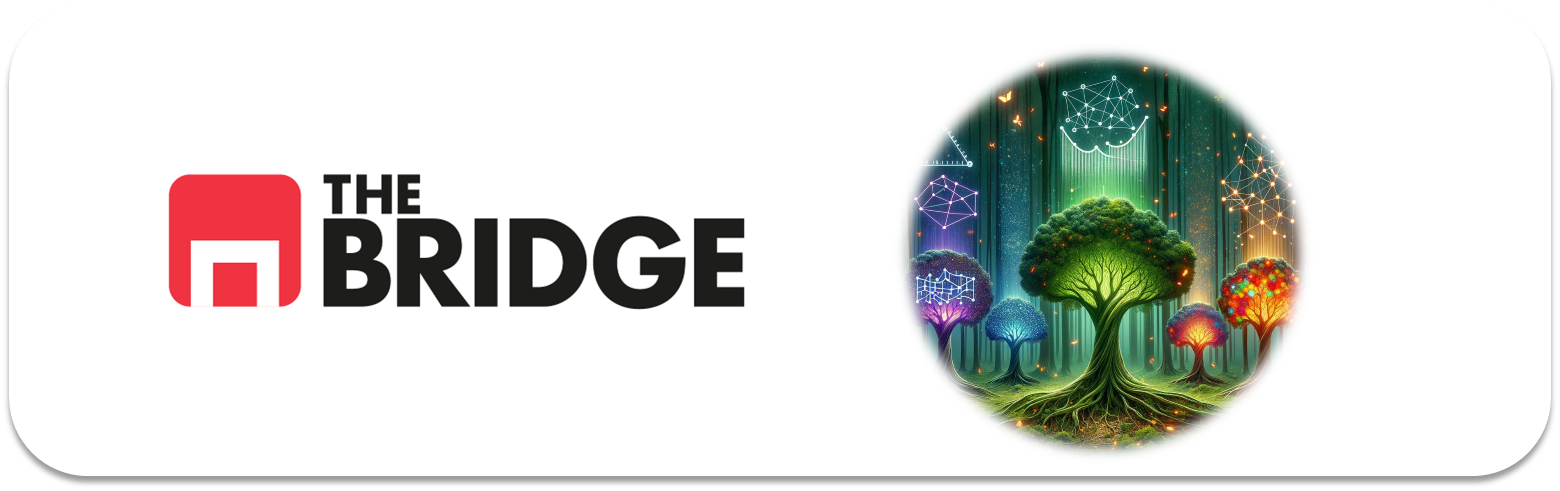

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

In [2]:
df = pd.read_csv("./data/bank-full.csv", sep = ";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [3]:
target = "y"


<Axes: xlabel='y', ylabel='count'>

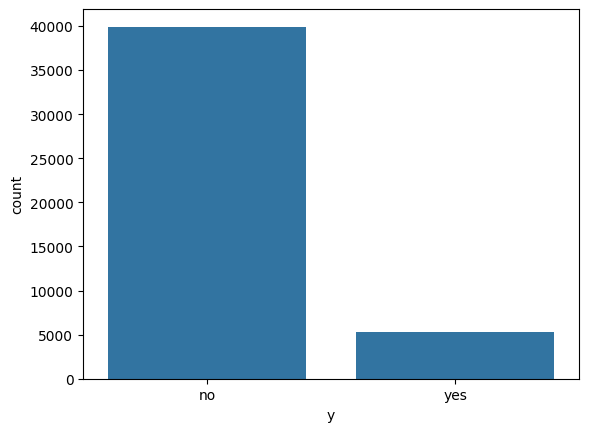

In [4]:
# visualizo el target, para ver si está muy desbalanceado, dado que es binaria combienve verlo con sns.countplot
sns.countplot(x=target, data=df)

In [45]:
print(f"Tasa de yes: {100*y.mean():.2f}%")

Tasa de yes: 11.70%


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
# es verdad que no tengo nulos pero hay varios "unknown" por lo que los vamos a contar

cols_obj = df.select_dtypes(include= "object").columns
for col in cols_obj:
    proporcion_unknown = (df[col] == "unknown").mean()
    print(col, proporcion_unknown) 


job 0.006370131162770122
marital 0.0
education 0.04107407489327818
default 0.0
housing 0.0
loan 0.0
contact 0.28798301298356593
month 0.0
poutcome 0.8174780473778506
y 0.0


In [7]:
# para que el modelo trabaje mejor, debe llevar los "yes" y "no" del target a "0" y "1"

df[target] = (df[target] == "yes").astype(int)
df[target]

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [8]:
df[target].value_counts()
df[target].mean()

np.float64(0.11698480458295547)

In [9]:
# Selección de features, vamos a dejar duration por fuera: 
# duration es leakage: es la duración de la llamada y se conoce después/durante la interacción
# En un escenario real “antes de llamar” no la tienes, y además suele inflar muchísimo el rendimiento

df_modelo = df.drop(columns= ["duration"])
X = df_modelo.drop(columns= [target])
y = df_modelo[target]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

In [11]:
train_set = X_train.copy()
train_set[target] = y_train.copy()

train_set

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,2,-1,0,unknown,0
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,4,185,7,failure,1
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,4,-1,0,unknown,1
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,11,-1,0,unknown,0
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,10,-1,0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17958,50,blue-collar,married,secondary,no,917,yes,no,cellular,30,jul,2,-1,0,unknown,0
15941,36,admin.,single,secondary,no,22,yes,no,cellular,22,jul,5,-1,0,unknown,0
16952,45,blue-collar,married,secondary,no,79,yes,no,cellular,25,jul,1,-1,0,unknown,0
34781,27,management,single,tertiary,no,2559,yes,no,cellular,6,may,1,-1,0,unknown,0


In [12]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36168 entries, 24001 to 44229
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        36168 non-null  int64 
 1   job        36168 non-null  object
 2   marital    36168 non-null  object
 3   education  36168 non-null  object
 4   default    36168 non-null  object
 5   balance    36168 non-null  int64 
 6   housing    36168 non-null  object
 7   loan       36168 non-null  object
 8   contact    36168 non-null  object
 9   day        36168 non-null  int64 
 10  month      36168 non-null  object
 11  campaign   36168 non-null  int64 
 12  pdays      36168 non-null  int64 
 13  previous   36168 non-null  int64 
 14  poutcome   36168 non-null  object
 15  y          36168 non-null  int64 
dtypes: int64(7), object(9)
memory usage: 4.7+ MB


In [16]:
# Arranco el Mini-EDA
features_cat = train_set.select_dtypes(include="object").columns.tolist()
features_cat


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [30]:
pct_unknown = {}

for col in features_cat:
    pct_unknown[col] = (train_set[col].astype(str).str.strip().str.lower() == "unknown").mean() * 100

pct_unknown = pd.Series(pct_unknown).sort_values(ascending=False)

for col, pct in pct_unknown.items():
    print(f"{col}: {pct:.2f}% unknown")

poutcome: 81.81% unknown
contact: 28.72% unknown
education: 4.10% unknown
job: 0.65% unknown
marital: 0.00% unknown
housing: 0.00% unknown
default: 0.00% unknown
loan: 0.00% unknown
month: 0.00% unknown


In [18]:
train_set[features_cat].nunique().sort_values(ascending=False)

job          12
month        12
education     4
poutcome      4
marital       3
contact       3
default       2
housing       2
loan          2
dtype: int64

In [ ]:
# Hemos visualizado el % de unknow en cada columna y la cardinalidad para evaluar si excluir o transformar features categoricas

#como target es 0-1 basicamente nos estamos viendo la proporcion de unos(1) que serían los yes vs el feature

for col in features_cat:
    tasa = train_set.groupby(col)[target].mean().sort_values(ascending= False)
    print("\n", col)
    print(tasa.head(10))



 job
job
student          0.288918
retired          0.229581
unemployed       0.154297
management       0.138597
admin.           0.122917
unknown          0.119658
self-employed    0.114240
technician       0.109262
services         0.089008
entrepreneur     0.085160
Name: y, dtype: float64

 marital
marital
single      0.150093
divorced    0.122542
married     0.100363
Name: y, dtype: float64

 education
education
tertiary     0.148858
unknown      0.132254
secondary    0.106729
primary      0.086241
Name: y, dtype: float64

 default
default
no     0.118043
yes    0.058733
Name: y, dtype: float64

 housing
housing
no     0.167334
yes    0.077098
Name: y, dtype: float64

 loan
loan
no     0.126338
yes    0.068123
Name: y, dtype: float64

 contact
contact
cellular     0.148349
telephone    0.139404
unknown      0.041113
Name: y, dtype: float64

 month
month
mar    0.508951
dec    0.471910
sep    0.452328
oct    0.437500
apr    0.195489
feb    0.167950
aug    0.109306
jun    0.104083
j

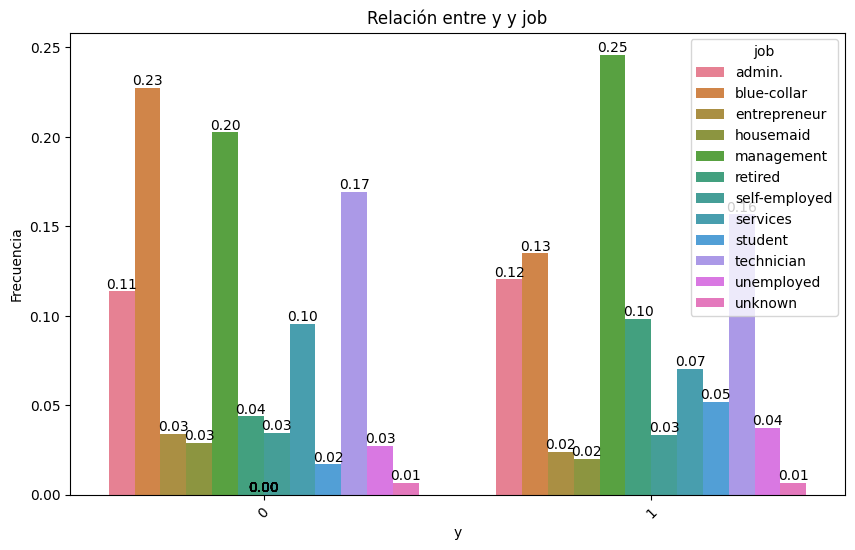

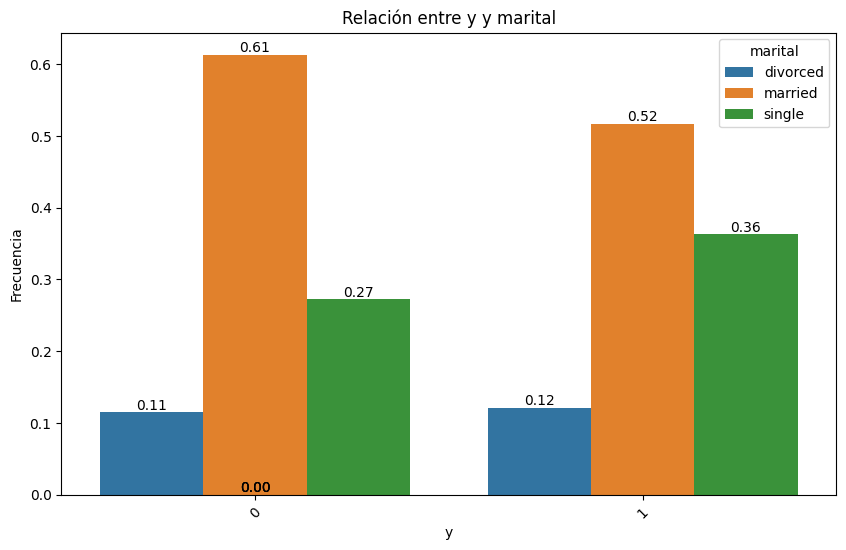

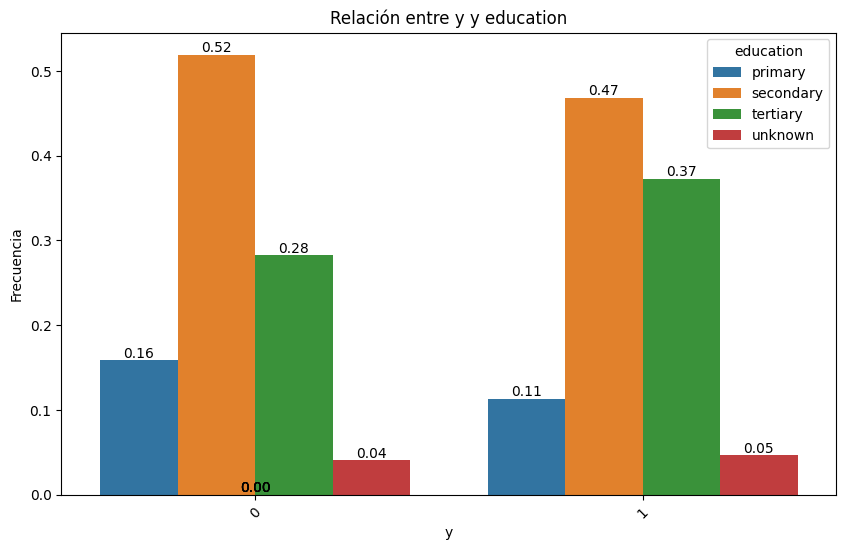

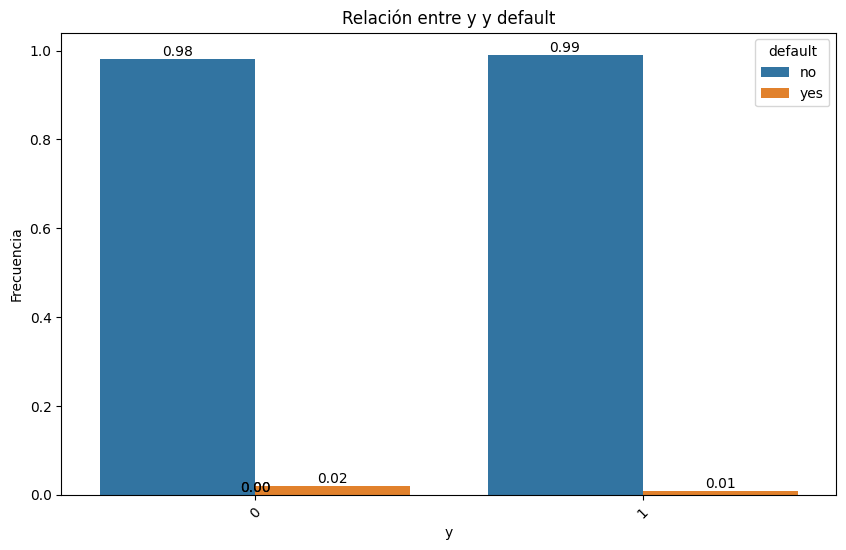

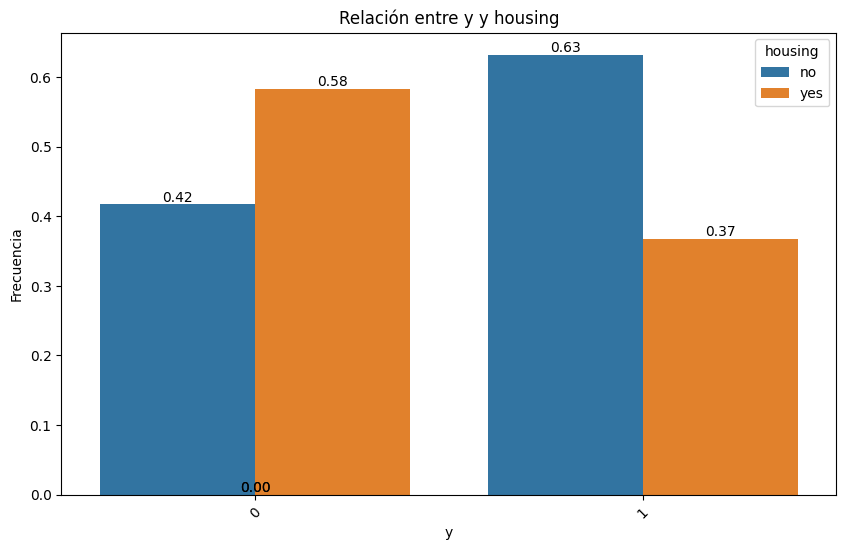

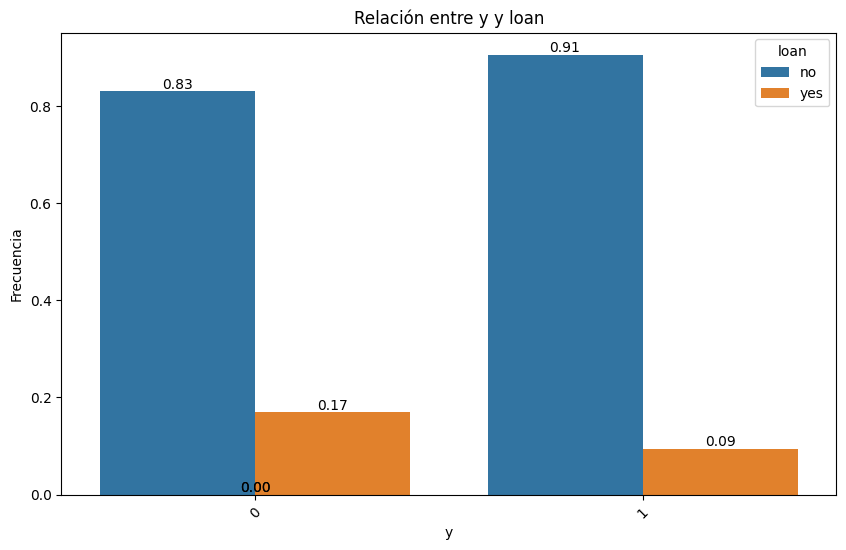

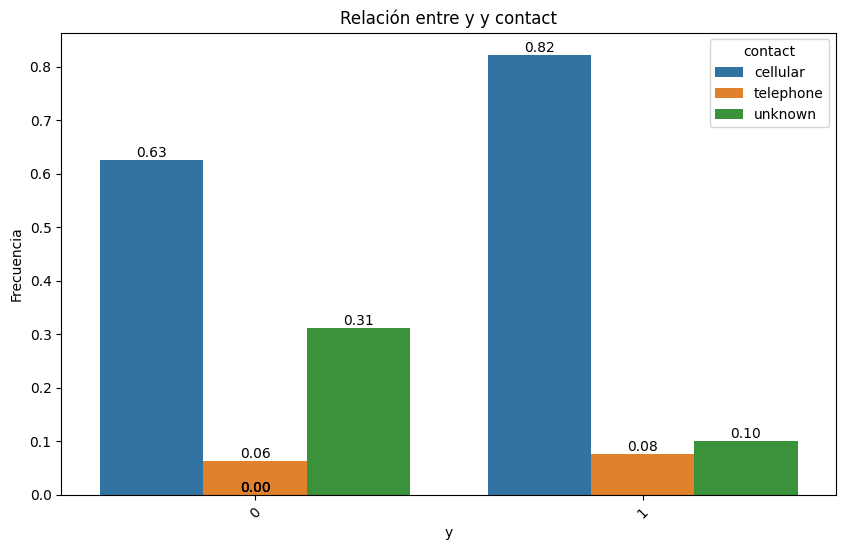

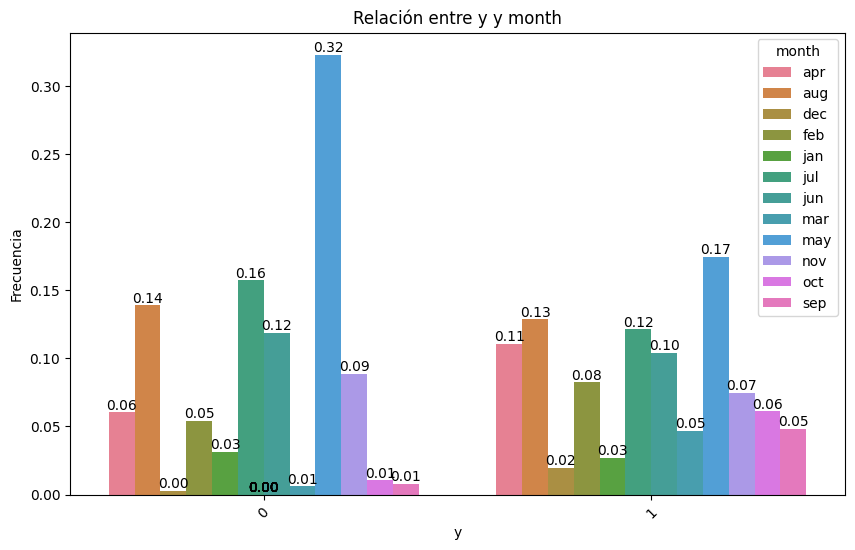

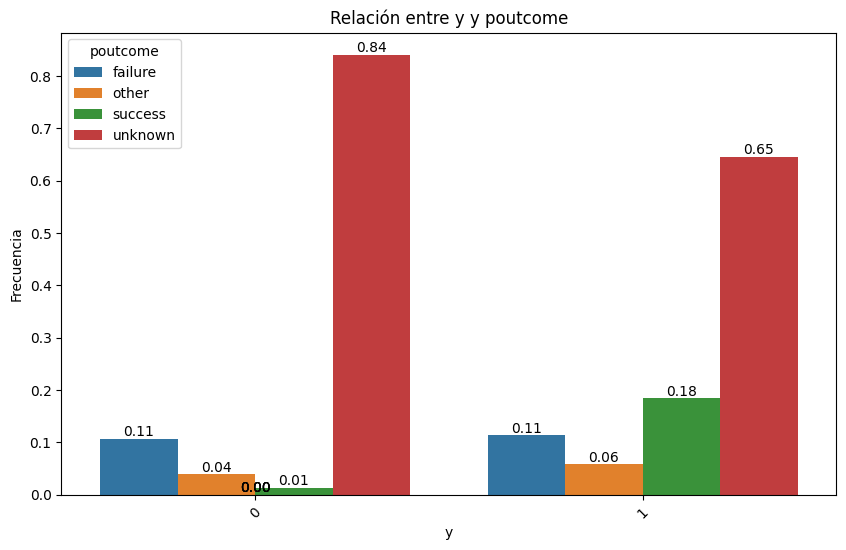

In [32]:
import bootcampviztools as bt

for feat in features_cat:
    bt.plot_categorical_relationship_fin(train_set, target, feat, show_values=True, relative_freq=True)


In [33]:
features_num = train_set.select_dtypes(include=["int64", "float64"]).columns.drop(target).tolist()

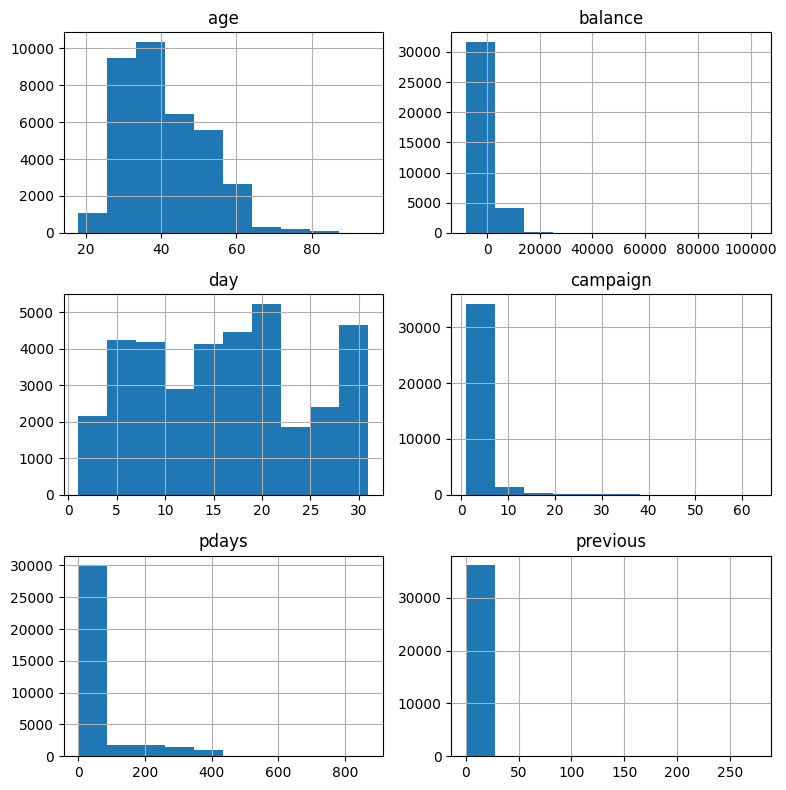

In [35]:
train_set[features_num].hist(figsize=(8, 8))
plt.tight_layout()

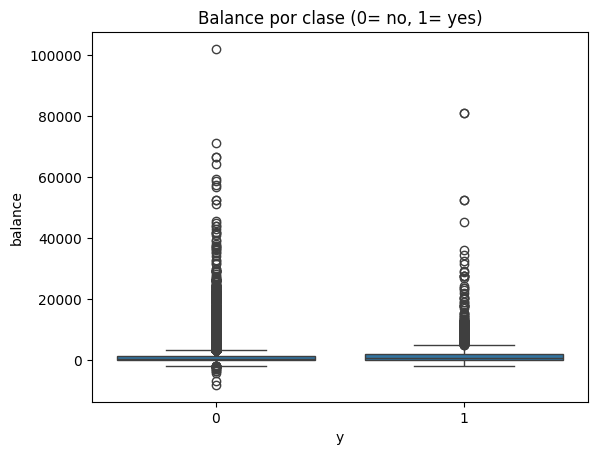

In [36]:
# De aquí podemos ver varias cosa spero para modelos de árboles de decisión realmente lo que nos importa es:
# ver tasa de "yes" por bins y lo haremos con un boxplot para balance

sns.boxplot(data=train_set, x= target, y= "balance")
plt.title("Balance por clase (0= no, 1= yes)")
plt.show()

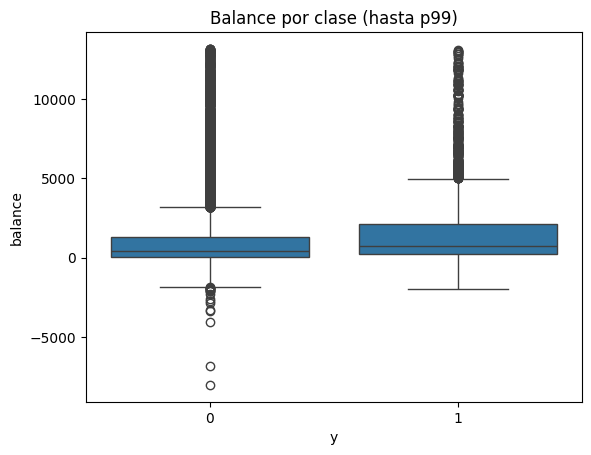

In [ ]:
#Aquí vamos a intentar ver mejor los boxplot, vamos a cortal en el cuantil 99% para ver todo sin ese 1%

lim = train_set["balance"].quantile(0.99)

sns.boxplot(data=train_set[train_set["balance"] <= lim], x=target, y="balance")
plt.title("Balance por clase (hasta percentil 99)")

plt.show()


In [ ]:
"duration" in X_train.columns # solo para comprobar que no se me coló duration

False

In [46]:
# Vamos a hacer un OneHOtEncoder para todas las categoricas no solo apra las yes no sino también para las multiclase

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown= "ignore", sparse_output= False)

X_train_cat_ohe = ohe.fit_transform(X_train[features_cat])
X_test_cat_ohe = ohe.transform(X_test[features_cat])

# Debo convertir las numericas en arrays dado que OHE me devuelve un array y es más facil para cuando las vaya a concatenar nuevamente
 
X_train_num = X_train[features_num].to_numpy()
X_test_num = X_test[features_num].to_numpy()

X_train_cat_ohe.shape, X_train_num.shape

((36168, 44), (36168, 6))

In [47]:
# concateno

X_train_final = np.hstack([X_train_cat_ohe, X_train_num])
X_test_final = np.hstack([X_test_cat_ohe, X_test_num])

print(X_train_final.shape, X_test_final.shape)

(36168, 50) (9043, 50)


In [48]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(random_state= 42)
arbol.fit(X_train_final, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# me traigo esta función de la practica anterior
 
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

def metrics_bank(model, X, y_target):
    y_pred = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y_target, y_pred)
    print(classification_report(y_target, y_pred))

TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31937
           1       1.00      1.00      1.00      4231

    accuracy                           1.00     36168
   macro avg       1.00      1.00      1.00     36168
weighted avg       1.00      1.00      1.00     36168



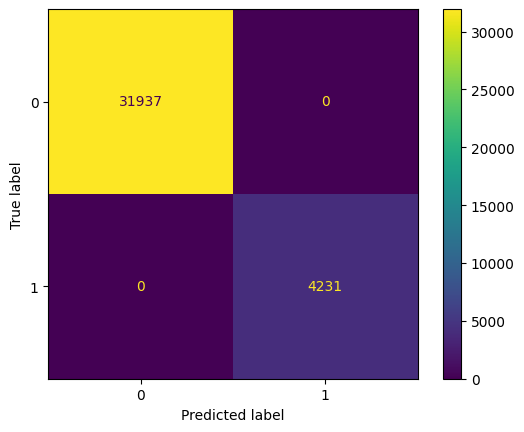

In [50]:
print("TRAIN")
metrics_bank(arbol, X_train_final, y_train)

TEST
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7985
           1       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.61      0.61      0.61      9043
weighted avg       0.84      0.83      0.84      9043



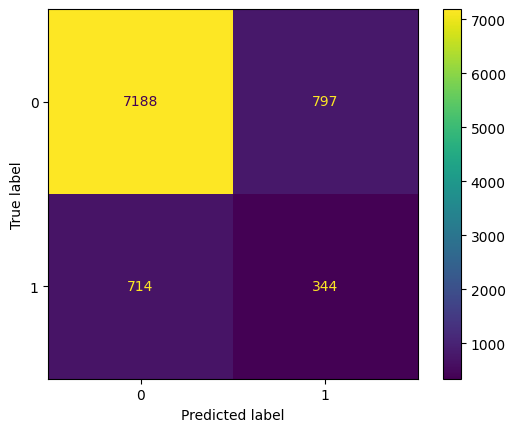

In [51]:
print("TEST")
metrics_bank(arbol, X_test_final, y_test)

In [53]:
# pues vemos que nos ha predecido 100%, perfecto por lo que está sobreajustado (overfitting) vamos a restringir un poco con hiper parametros para que generalice mejor

arbol_reg = DecisionTreeClassifier(random_state= 42, max_depth= 4, min_samples_leaf= 50, class_weight= "balanced")
arbol_reg.fit(X_train_final, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=50, random_state=42)

TRAIN
              precision    recall  f1-score   support

           0       0.93      0.77      0.84     31937
           1       0.25      0.58      0.35      4231

    accuracy                           0.75     36168
   macro avg       0.59      0.67      0.60     36168
weighted avg       0.85      0.75      0.79     36168



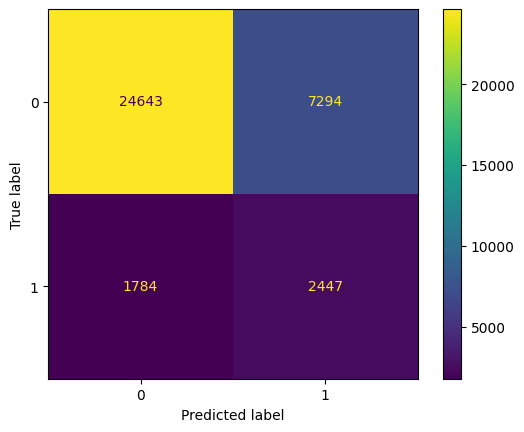

In [54]:
print("TRAIN")
metrics_bank(arbol_reg, X_train_final, y_train)

TEST
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      7985
           1       0.25      0.58      0.34      1058

    accuracy                           0.74      9043
   macro avg       0.59      0.67      0.59      9043
weighted avg       0.85      0.74      0.78      9043



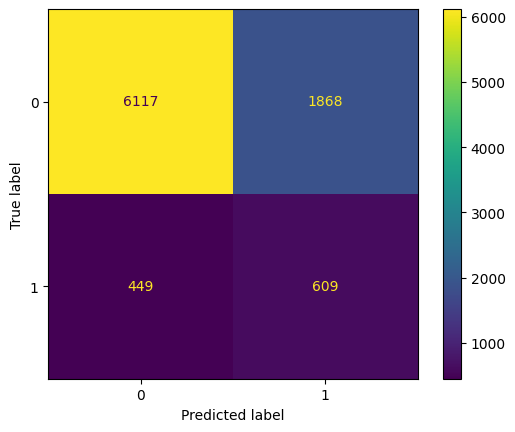

In [55]:
print("TEST")
metrics_bank(arbol_reg, X_test_final, y_test)

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_leaf": [10, 50, 100, 200],
    "min_samples_split": [2, 10, 50],
    "class_weight": [None, "balanced"]
}

arbol = DecisionTreeClassifier(random_state=42)

 # para desbalance: f1 de la clase 1 (por defecto en binario es para la positiva)
grid = GridSearchCV(estimator= arbol,param_grid= param_grid, scoring= "f1", cv=5, n_jobs=-1, verbose=1)

grid.fit(X_train_final, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [3, 4, 5, 6, None],
                         'min_samples_leaf': [10, 50, 100, 200],
                         'min_samples_split': [2, 10, 50]},
             scoring='f1', verbose=1)

In [57]:
print("Mejores parámetros:", grid.best_params_)


Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 50}


In [58]:
print("Mejor score (f1):", grid.best_score_)

Mejor score (f1): 0.4104610844665813


In [59]:
best_tree = grid.best_estimator_

TRAIN
              precision    recall  f1-score   support

           0       0.93      0.86      0.90     31937
           1       0.34      0.54      0.42      4231

    accuracy                           0.82     36168
   macro avg       0.64      0.70      0.66     36168
weighted avg       0.86      0.82      0.84     36168



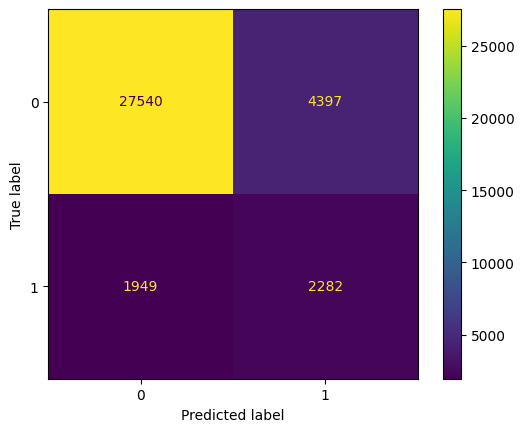

In [60]:
print("TRAIN")
metrics_bank(best_tree, X_train_final, y_train)

TEST
              precision    recall  f1-score   support

           0       0.93      0.86      0.90      7985
           1       0.34      0.55      0.42      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.70      0.66      9043
weighted avg       0.87      0.82      0.84      9043



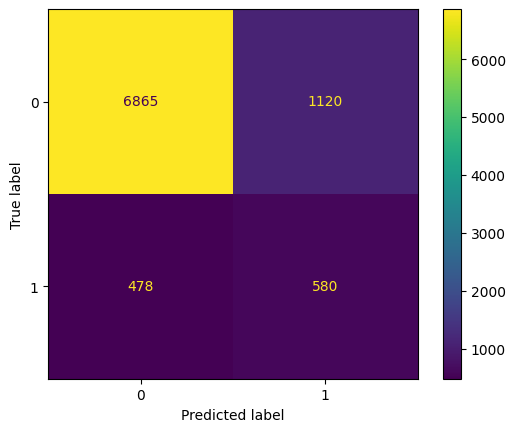

In [61]:
print("TEST")
metrics_bank(best_tree, X_test_final, y_test)

In [62]:
# Regresión logística

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_final, y_train)

c:\Users\helad\OneDrive\Escritorio\DataSience\DS-Online-Roman\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

TRAIN RegresiónLog
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     31937
           1       0.68      0.16      0.26      4231

    accuracy                           0.89     36168
   macro avg       0.79      0.58      0.60     36168
weighted avg       0.87      0.89      0.86     36168



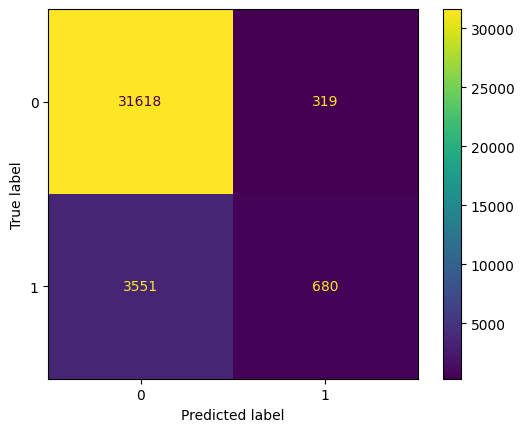

In [66]:
print("TRAIN RegresiónLog")
metrics_bank(log_reg, X_train_final, y_train)

TEST RegresiónLog
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.16      0.26      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.57      0.60      9043
weighted avg       0.87      0.89      0.86      9043



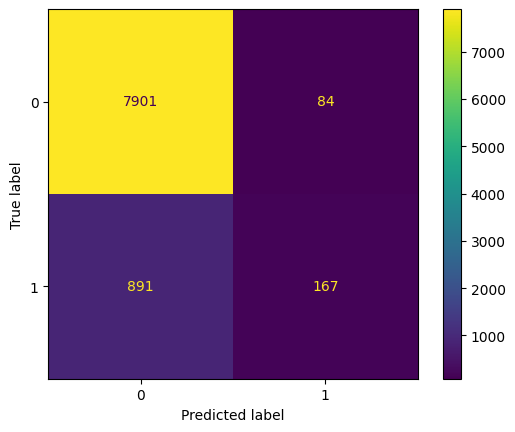

In [65]:
print("TEST RegresiónLog")
metrics_bank(log_reg, X_test_final, y_test)

El target está bastante desbalanceado: solo alrededor de un 11.7% de los casos son “yes”. Por eso, además de mirar accuracy, tiene sentido fijarse sobre todo en métricas de la clase positiva (recall y F1), porque si no es fácil caer en un modelo que “acierta mucho” simplemente prediciendo casi siempre “no”.

Como baseline, la regresión logística (con hiperparámetros por defecto) da una accuracy alta (~0.89), pero en la clase 1 se queda con un recall muy bajo (~0.16) y un F1 también bajo (~0.26). Es decir, cuando predice “yes” suele acertar (precision ~0.67), pero detecta muy pocos de los “yes” reales, lo que en la práctica significaría perder muchas oportunidades.

En cambio, el árbol optimizado con GridSearch (max_depth=6, min_samples_split=50, min_samples_leaf=10 y class_weight='balanced') mejora claramente el rendimiento en la clase 1, alcanzando un recall de ~0.55 y un F1 de ~0.42 en test. Además, las métricas en train y test son muy parecidas, lo que sugiere que el modelo no está sobreajustando de forma importante.

En resumen, si el objetivo es maximizar la captación de clientes que sí contratarían el depósito, me quedaría con el árbol optimizado (mejor recall/F1 para “yes”). Si el objetivo fuera ser más conservador y reducir falsos positivos (por ejemplo, minimizar llamadas innecesarias), la regresión logística podría ser preferible por su mayor precision en la clase positiva.